# Fusion vs Other Trackers — Fair OTB Comparison

This notebook compares the successful learned Fusion framework against other trackers using the **same sequences, frames, initialization, and metrics**.

## Trackers evaluated directly

- MOSSE
- KCF
- CSRT / CSRDCF-style
- Pretrained SiamRPN
- Learned Weighted Fusion

## Optional trajectory-based trackers

The notebook can also include:

- SiamFC
- SiamRPN++
- ECO
- ATOM
- DiMP

when their prediction files are placed in the expected folders.

## Metrics

- Success AUC
- Precision@20

## Fair-comparison rule

All directly compared trackers are evaluated on the same OTB sequences and the same maximum-frame limit used by the successful Fusion experiment.


## 0. Install OpenCV contrib


In [ ]:
!pip install -q     opencv-contrib-python-headless==4.10.0.84     pandas     numpy     matplotlib     tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 MB 16.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## 1. Configuration


In [ ]:
from pathlib import Path
import gc
import json
import math
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/MethodologyAlignedFusion"
)

OTB_ROOT = Path(
    "/content/drive/MyDrive/OTB2013_Dataset"
)

CACHE_ROOT = PROJECT_ROOT / "cache"
FUSION_RESULT_ROOT = PROJECT_ROOT / "results"
FUSION_TRAJECTORY_ROOT = (
    FUSION_RESULT_ROOT
    / "trajectories"
)

COMPARISON_ROOT = (
    PROJECT_ROOT
    / "tracker_comparison"
)

BASELINE_TRAJECTORY_ROOT = (
    COMPARISON_ROOT
    / "trajectories"
)

FIGURE_ROOT = (
    COMPARISON_ROOT
    / "figures"
)

for path in [
    COMPARISON_ROOT,
    BASELINE_TRAJECTORY_ROOT,
    FIGURE_ROOT,
]:
    path.mkdir(
        parents=True,
        exist_ok=True,
    )

# Must match the successful Fusion experiment.
SEQUENCE_NAMES = [
    "Basketball",
    "Bolt",
    "Boy",
    "Car4",
]

MAX_FRAMES = 100

# Optional advanced tracker trajectories.
OPTIONAL_TRACKER_ROOTS = {
    "SiamFC": (
        "/content/drive/MyDrive/OTB_Tracker_Results/SiamFC"
    ),
    "SiamRPN++": (
        "/content/drive/MyDrive/OTB_Tracker_Results/SiamRPN++"
    ),
    "ECO": (
        "/content/drive/MyDrive/OTB_Tracker_Results/ECO"
    ),
    "ATOM": (
        "/content/drive/MyDrive/OTB_Tracker_Results/ATOM"
    ),
    "DiMP": (
        "/content/drive/MyDrive/OTB_Tracker_Results/DiMP"
    ),
}

print("OpenCV:", cv2.__version__)
print("Comparison output:", COMPARISON_ROOT)


OpenCV: 4.10.0
Comparison output: /content/drive/MyDrive/MethodologyAlignedFusion/tracker_comparison


## 2. Load OTB sequences


In [ ]:
def parse_boxes(path):
    rows = []

    with open(
        path,
        "r",
        encoding="utf-8-sig",
    ) as file:
        for raw in file:
            raw = raw.strip()

            if not raw:
                continue

            values = [
                float(value)
                for value in raw
                .replace("\t", ",")
                .replace(" ", ",")
                .split(",")
                if value != ""
            ]

            if len(values) == 4:
                rows.append(values)

            elif len(values) == 8:
                xs = values[0::2]
                ys = values[1::2]

                rows.append([
                    min(xs),
                    min(ys),
                    max(xs) - min(xs),
                    max(ys) - min(ys),
                ])

    return np.asarray(
        rows,
        dtype=np.float32,
    )


def load_sequence(
    root,
    sequence_name,
    max_frames=None,
):
    sequence_directory = (
        Path(root)
        / sequence_name
    )

    image_directory = (
        sequence_directory
        / "img"
    )

    images = sorted(
        list(
            image_directory.glob(
                "*.jpg"
            )
        )
        + list(
            image_directory.glob(
                "*.jpeg"
            )
        )
        + list(
            image_directory.glob(
                "*.png"
            )
        )
    )

    ground_truth_files = sorted(
        sequence_directory.glob(
            "groundtruth_rect*.txt"
        )
    )

    if not images or not ground_truth_files:
        raise FileNotFoundError(
            sequence_directory
        )

    ground_truth = parse_boxes(
        ground_truth_files[0]
    )

    frame_count = min(
        len(images),
        len(ground_truth),
    )

    if max_frames is not None:
        frame_count = min(
            frame_count,
            max_frames,
        )

    return {
        "name": sequence_name,
        "images": [
            str(path)
            for path
            in images[:frame_count]
        ],
        "ground_truth": (
            ground_truth[:frame_count]
        ),
    }


sequences = {
    name: load_sequence(
        OTB_ROOT,
        name,
        max_frames=MAX_FRAMES,
    )
    for name in SEQUENCE_NAMES
}

for name, sequence in sequences.items():
    print(
        name,
        len(sequence["images"]),
        "frames",
    )


Basketball 100 frames
Bolt 100 frames
Boy 100 frames
Car4 100 frames


## 3. OTB Success and Precision metrics


In [ ]:
def aligned_iou(
    predictions,
    ground_truth,
):
    x1 = np.maximum(
        predictions[:, 0],
        ground_truth[:, 0],
    )

    y1 = np.maximum(
        predictions[:, 1],
        ground_truth[:, 1],
    )

    x2 = np.minimum(
        predictions[:, 0]
        + predictions[:, 2],
        ground_truth[:, 0]
        + ground_truth[:, 2],
    )

    y2 = np.minimum(
        predictions[:, 1]
        + predictions[:, 3],
        ground_truth[:, 1]
        + ground_truth[:, 3],
    )

    intersection = (
        np.maximum(
            0,
            x2 - x1,
        )
        * np.maximum(
            0,
            y2 - y1,
        )
    )

    prediction_area = (
        np.maximum(
            predictions[:, 2],
            0,
        )
        * np.maximum(
            predictions[:, 3],
            0,
        )
    )

    ground_truth_area = (
        np.maximum(
            ground_truth[:, 2],
            0,
        )
        * np.maximum(
            ground_truth[:, 3],
            0,
        )
    )

    union = (
        prediction_area
        + ground_truth_area
        - intersection
    )

    return np.divide(
        intersection,
        union,
        out=np.zeros_like(
            intersection
        ),
        where=union > 0,
    )


def center_errors(
    predictions,
    ground_truth,
):
    prediction_centers = np.column_stack([
        predictions[:, 0]
        + predictions[:, 2] / 2.0,
        predictions[:, 1]
        + predictions[:, 3] / 2.0,
    ])

    ground_truth_centers = np.column_stack([
        ground_truth[:, 0]
        + ground_truth[:, 2] / 2.0,
        ground_truth[:, 1]
        + ground_truth[:, 3] / 2.0,
    ])

    return np.linalg.norm(
        prediction_centers
        - ground_truth_centers,
        axis=1,
    )


def align_predictions(
    predictions,
    ground_truth,
):
    predictions = np.asarray(
        predictions,
        dtype=np.float32,
    )

    ground_truth = np.asarray(
        ground_truth,
        dtype=np.float32,
    )

    if (
        len(predictions)
        == len(ground_truth) - 1
    ):
        predictions = np.vstack([
            ground_truth[0],
            predictions,
        ])

    frame_count = min(
        len(predictions),
        len(ground_truth),
    )

    return (
        predictions[:frame_count],
        ground_truth[:frame_count],
    )


def evaluate_boxes(
    predictions,
    ground_truth,
):
    predictions, ground_truth = (
        align_predictions(
            predictions,
            ground_truth,
        )
    )

    predictions = predictions[1:]
    ground_truth = ground_truth[1:]

    ious = aligned_iou(
        predictions,
        ground_truth,
    )

    errors = center_errors(
        predictions,
        ground_truth,
    )

    success_thresholds = np.linspace(
        0,
        1,
        101,
    )

    precision_thresholds = np.arange(
        0,
        51,
    )

    success_curve = np.asarray([
        (ious >= threshold).mean()
        for threshold
        in success_thresholds
    ])

    precision_curve = np.asarray([
        (errors <= threshold).mean()
        for threshold
        in precision_thresholds
    ])

    return {
        "success_auc": float(
            np.trapezoid(
                success_curve,
                success_thresholds,
            )
        ),
        "precision_20px": float(
            (errors <= 20).mean()
        ),
        "success_curve": (
            success_curve
        ),
        "precision_curve": (
            precision_curve
        ),
    }


## 4. OpenCV baseline tracker constructors


In [ ]:
def create_tracker(kind):
    kind = kind.upper()

    constructor_names = {
        "MOSSE": [
            "TrackerMOSSE_create",
        ],
        "KCF": [
            "TrackerKCF_create",
        ],
        "CSRT": [
            "TrackerCSRT_create",
        ],
    }

    if kind not in constructor_names:
        raise ValueError(kind)

    for constructor_name in constructor_names[
        kind
    ]:
        if hasattr(
            cv2,
            constructor_name,
        ):
            return (
                getattr(
                    cv2,
                    constructor_name,
                )()
            )

        if (
            hasattr(cv2, "legacy")
            and hasattr(
                cv2.legacy,
                constructor_name,
            )
        ):
            return (
                getattr(
                    cv2.legacy,
                    constructor_name,
                )()
            )

    raise RuntimeError(
        f"{kind} is unavailable. "
        "Disconnect and delete the runtime, "
        "then run the installation cell again."
    )


for tracker_name in [
    "MOSSE",
    "KCF",
    "CSRT",
]:
    tracker = create_tracker(
        tracker_name
    )

    print(
        tracker_name,
        "ready",
    )

    del tracker


MOSSE ready
KCF ready
CSRT ready


## 5. Run MOSSE, KCF, and CSRT


In [ ]:
def integer_box(box):
    return tuple(
        int(round(float(value)))
        for value in box
    )


def valid_box(box):
    if box is None or len(box) != 4:
        return False

    values = np.asarray(
        box,
        dtype=np.float32,
    )

    return (
        np.isfinite(values).all()
        and values[2] > 1
        and values[3] > 1
    )


def clip_box(
    box,
    image_shape,
):
    image_height, image_width = (
        image_shape[:2]
    )

    x, y, width, height = map(
        float,
        box,
    )

    width = np.clip(
        width,
        2,
        image_width,
    )

    height = np.clip(
        height,
        2,
        image_height,
    )

    x = np.clip(
        x,
        0,
        max(
            image_width - width,
            0,
        ),
    )

    y = np.clip(
        y,
        0,
        max(
            image_height - height,
            0,
        ),
    )

    return np.asarray(
        [x, y, width, height],
        dtype=np.float32,
    )


def run_opencv_tracker(
    sequence,
    tracker_kind,
):
    images = sequence["images"]
    ground_truth = sequence[
        "ground_truth"
    ]

    frame_count = len(images)

    predictions = np.zeros(
        (frame_count, 4),
        dtype=np.float32,
    )

    first_frame = cv2.imread(
        images[0]
    )

    initial_box = clip_box(
        ground_truth[0],
        first_frame.shape,
    )

    tracker = create_tracker(
        tracker_kind
    )

    tracker.init(
        first_frame,
        integer_box(initial_box),
    )

    predictions[0] = initial_box
    previous_box = initial_box.copy()

    start_time = time.perf_counter()

    for frame_index in range(
        1,
        frame_count,
    ):
        frame = cv2.imread(
            images[frame_index]
        )

        success, predicted_box = (
            tracker.update(
                frame
            )
        )

        if (
            success
            and valid_box(
                predicted_box
            )
        ):
            previous_box = clip_box(
                predicted_box,
                frame.shape,
            )

        predictions[
            frame_index
        ] = previous_box

    elapsed = (
        time.perf_counter()
        - start_time
    )

    fps = (
        (frame_count - 1)
        / elapsed
        if elapsed > 0
        else np.nan
    )

    return (
        predictions,
        fps,
    )


baseline_outputs = {}

for tracker_kind in [
    "MOSSE",
    "KCF",
    "CSRT",
]:
    baseline_outputs[
        tracker_kind
    ] = {}

    tracker_directory = (
        BASELINE_TRAJECTORY_ROOT
        / tracker_kind
    )

    tracker_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    for sequence_name, sequence in tqdm(
        sequences.items(),
        desc=tracker_kind,
    ):
        output_file = (
            tracker_directory
            / f"{sequence_name}.txt"
        )

        metadata_file = (
            tracker_directory
            / f"{sequence_name}_meta.json"
        )

        if output_file.exists():
            predictions = parse_boxes(
                output_file
            )

            if metadata_file.exists():
                metadata = json.loads(
                    metadata_file.read_text()
                )

                fps = float(
                    metadata.get(
                        "fps",
                        np.nan,
                    )
                )

            else:
                fps = np.nan

        else:
            predictions, fps = (
                run_opencv_tracker(
                    sequence,
                    tracker_kind,
                )
            )

            np.savetxt(
                output_file,
                predictions,
                delimiter=",",
                fmt="%.6f",
            )

            metadata_file.write_text(
                json.dumps(
                    {
                        "fps": fps,
                    },
                    indent=2,
                )
            )

        baseline_outputs[
            tracker_kind
        ][sequence_name] = {
            "boxes": predictions,
            "fps": fps,
        }

        gc.collect()


MOSSE:   0%|          | 0/4 [00:00<?, ?it/s]

KCF:   0%|          | 0/4 [00:00<?, ?it/s]

CSRT:   0%|          | 0/4 [00:00<?, ?it/s]

## 6. Load saved SiamRPN and Fusion trajectories


In [ ]:
def find_existing_file(
    candidates,
):
    for candidate in candidates:
        candidate = Path(candidate)

        if candidate.exists():
            return candidate

    return None


def load_npz_branch(
    sequence_name,
    key,
):
    cache_file = (
        CACHE_ROOT
        / f"{sequence_name}_branches.npz"
    )

    if not cache_file.exists():
        raise FileNotFoundError(
            cache_file
        )

    cached = np.load(
        cache_file
    )

    if key not in cached.files:
        raise KeyError(
            f"{key} missing from {cache_file}"
        )

    return cached[key]


saved_outputs = {
    "Pretrained SiamRPN": {},
    "Learned Weighted Fusion": {},
}

for sequence_name in SEQUENCE_NAMES:
    saved_outputs[
        "Pretrained SiamRPN"
    ][sequence_name] = {
        "boxes": load_npz_branch(
            sequence_name,
            "siam_boxes",
        ),
        "fps": np.nan,
    }

    fusion_file = find_existing_file([
        FUSION_TRAJECTORY_ROOT
        / f"{sequence_name}.txt",
        FUSION_TRAJECTORY_ROOT
        / "Learned_Weighted_Fusion"
        / f"{sequence_name}.txt",
    ])

    if fusion_file is None:
        raise FileNotFoundError(
            f"Missing Fusion trajectory for {sequence_name}. "
            f"Expected under {FUSION_TRAJECTORY_ROOT}"
        )

    saved_outputs[
        "Learned Weighted Fusion"
    ][sequence_name] = {
        "boxes": parse_boxes(
            fusion_file
        ),
        "fps": np.nan,
    }

print(
    "Loaded SiamRPN and Fusion trajectories."
)


Loaded SiamRPN and Fusion trajectories.


## 7. Load optional advanced tracker trajectories


In [ ]:
optional_outputs = {}
optional_status_rows = []

for tracker_name, root_string in (
    OPTIONAL_TRACKER_ROOTS.items()
):
    root = Path(
        root_string
    )

    tracker_predictions = {}
    missing_sequences = []

    for sequence_name in SEQUENCE_NAMES:
        candidates = [
            root
            / f"{sequence_name}.txt",

            root
            / f"{sequence_name.lower()}.txt",

            root
            / f"{sequence_name}_001.txt",

            root
            / sequence_name
            / f"{sequence_name}.txt",
        ]

        trajectory_file = (
            find_existing_file(
                candidates
            )
        )

        if trajectory_file is None:
            missing_sequences.append(
                sequence_name
            )

        else:
            tracker_predictions[
                sequence_name
            ] = {
                "boxes": parse_boxes(
                    trajectory_file
                ),
                "fps": np.nan,
            }

    available = (
        len(missing_sequences) == 0
    )

    optional_status_rows.append({
        "tracker": tracker_name,
        "available": available,
        "missing_sequences": (
            ", ".join(
                missing_sequences
            )
        ),
        "root": str(root),
    })

    if available:
        optional_outputs[
            tracker_name
        ] = tracker_predictions


optional_status_df = pd.DataFrame(
    optional_status_rows
)

display(optional_status_df)


,tracker,available,missing_sequences,root
0,SiamFC,False,"Basketball, Bolt, Boy, Car4",/content/drive/MyDrive/OTB_Tracker_Results/SiamFC
1,SiamRPN++,False,"Basketball, Bolt, Boy, Car4",/content/drive/MyDrive/OTB_Tracker_Results/Sia...
2,ECO,False,"Basketball, Bolt, Boy, Car4",/content/drive/MyDrive/OTB_Tracker_Results/ECO
3,ATOM,False,"Basketball, Bolt, Boy, Car4",/content/drive/MyDrive/OTB_Tracker_Results/ATOM
4,DiMP,False,"Basketball, Bolt, Boy, Car4",/content/drive/MyDrive/OTB_Tracker_Results/DiMP


## 8. Evaluate all available trackers


In [ ]:
all_tracker_outputs = {}

all_tracker_outputs.update(
    baseline_outputs
)

all_tracker_outputs.update(
    saved_outputs
)

all_tracker_outputs.update(
    optional_outputs
)

rows = []
curves = {}

for tracker_name, tracker_sequences in (
    all_tracker_outputs.items()
):
    curves[tracker_name] = {
        "success": [],
        "precision": [],
    }

    for sequence_name in SEQUENCE_NAMES:
        sequence = sequences[
            sequence_name
        ]

        output = tracker_sequences[
            sequence_name
        ]

        result = evaluate_boxes(
            output["boxes"],
            sequence[
                "ground_truth"
            ],
        )

        rows.append({
            "tracker": tracker_name,
            "sequence": sequence_name,
            "success_auc": (
                result[
                    "success_auc"
                ]
            ),
            "precision_20px": (
                result[
                    "precision_20px"
                ]
            ),
            "fps": output.get(
                "fps",
                np.nan,
            ),
        })

        curves[
            tracker_name
        ]["success"].append(
            result[
                "success_curve"
            ]
        )

        curves[
            tracker_name
        ]["precision"].append(
            result[
                "precision_curve"
            ]
        )


per_sequence_df = pd.DataFrame(
    rows
)

summary_df = (
    per_sequence_df
    .groupby(
        "tracker",
        as_index=False,
    )
    .agg({
        "success_auc": "mean",
        "precision_20px": "mean",
        "fps": "mean",
    })
    .sort_values(
        [
            "success_auc",
            "precision_20px",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

summary_df[
    "rank_success"
] = (
    summary_df[
        "success_auc"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

summary_df[
    "rank_precision"
] = (
    summary_df[
        "precision_20px"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

display(summary_df)
display(per_sequence_df)

summary_df.to_csv(
    COMPARISON_ROOT
    / "tracker_comparison_summary.csv",
    index=False,
)

per_sequence_df.to_csv(
    COMPARISON_ROOT
    / "tracker_comparison_per_sequence.csv",
    index=False,
)


,tracker,success_auc,precision_20px,fps,rank_success,rank_precision
0,Learned Weighted Fusion,0.765442,0.997475,NaN,1,1
1,Pretrained SiamRPN,0.748687,0.989899,NaN,2,3
2,CSRT,0.737841,0.994949,32.840883,3,2
3,KCF,0.549912,0.770202,115.492338,4,4
4,MOSSE,0.478712,0.739899,2.584833,5,5


,tracker,sequence,success_auc,precision_20px,fps
0,MOSSE,Basketball,0.139646,0.171717,6.465427
1,MOSSE,Bolt,0.476414,0.979798,1.133158
2,MOSSE,Boy,0.481061,0.808081,1.258167
3,MOSSE,Car4,0.817727,1.000000,1.482580
4,KCF,Basketball,0.151061,0.191919,129.367042
5,KCF,Bolt,0.491364,1.000000,105.969214
6,KCF,Boy,0.756717,0.888889,119.616833
7,KCF,Car4,0.800505,1.000000,107.016260
8,CSRT,Basketball,0.479798,0.979798,32.360615
9,CSRT,Bolt,0.768737,1.000000,28.129616


## 9. Success plot


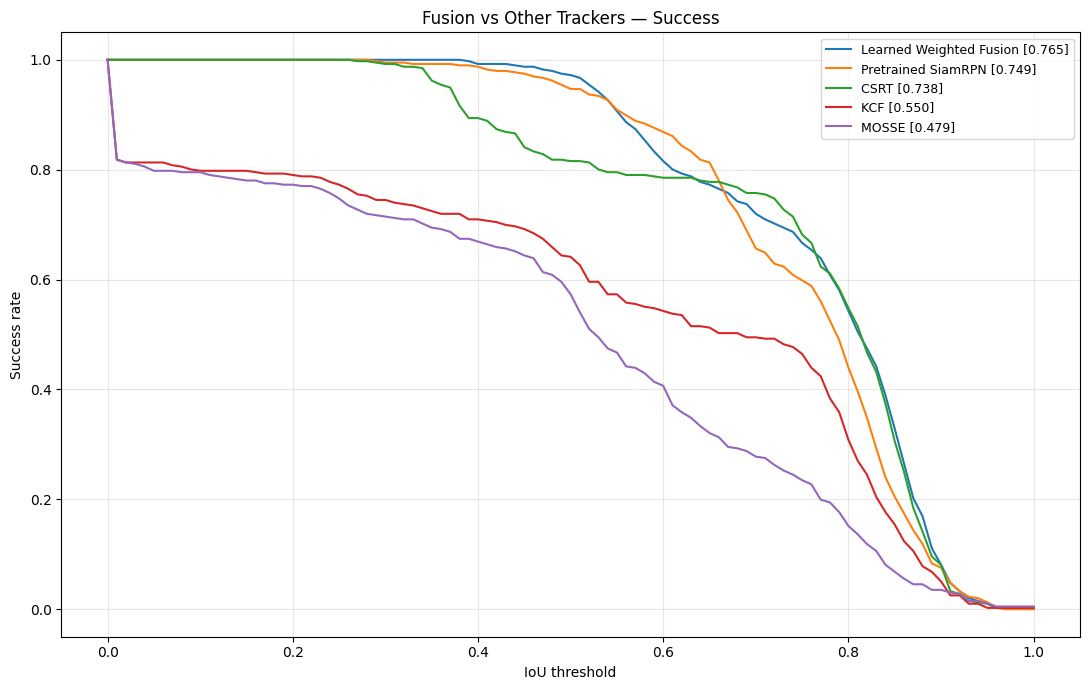

Saved: /content/drive/MyDrive/MethodologyAlignedFusion/tracker_comparison/figures/tracker_success_comparison.png


In [ ]:
success_thresholds = np.linspace(
    0,
    1,
    101,
)

plt.figure(
    figsize=(11, 7)
)

for tracker_name in summary_df[
    "tracker"
]:
    mean_curve = np.mean(
        curves[
            tracker_name
        ]["success"],
        axis=0,
    )

    auc = float(
        np.trapezoid(
            mean_curve,
            success_thresholds,
        )
    )

    plt.plot(
        success_thresholds,
        mean_curve,
        label=(
            f"{tracker_name} "
            f"[{auc:.3f}]"
        ),
    )

plt.xlabel("IoU threshold")
plt.ylabel("Success rate")
plt.title(
    "Fusion vs Other Trackers — Success"
)
plt.grid(True, alpha=0.3)
plt.legend(
    loc="best",
    fontsize=9,
)
plt.tight_layout()

success_plot_path = (
    FIGURE_ROOT
    / "tracker_success_comparison.png"
)

plt.savefig(
    success_plot_path,
    dpi=300,
)

plt.show()

print(
    "Saved:",
    success_plot_path,
)


## 10. Precision plot


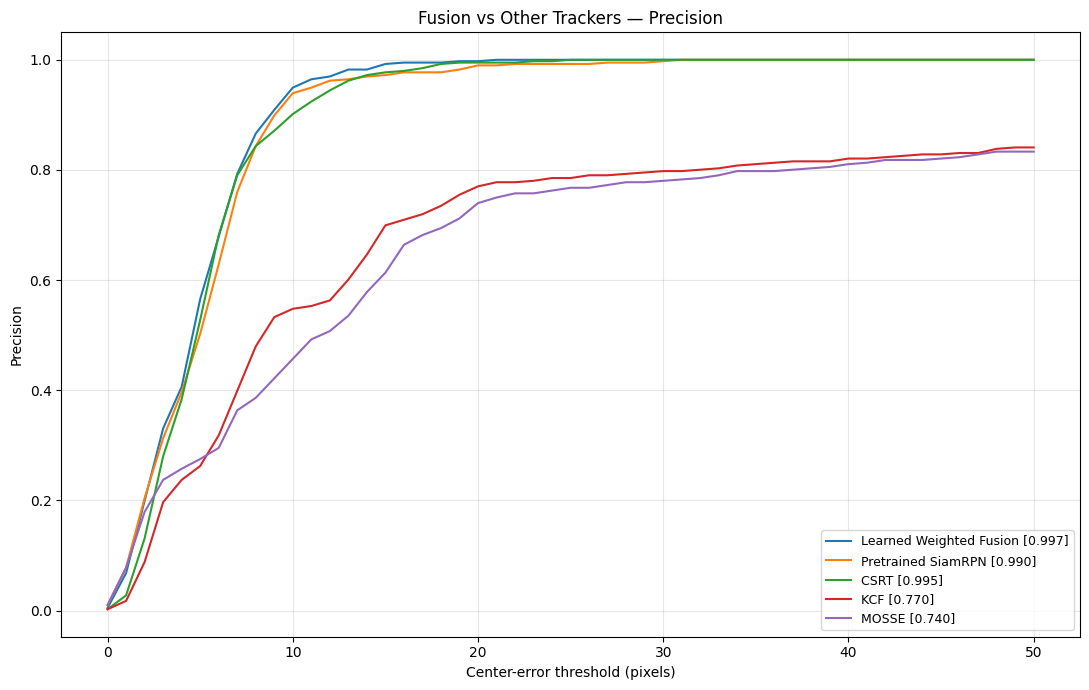

Saved: /content/drive/MyDrive/MethodologyAlignedFusion/tracker_comparison/figures/tracker_precision_comparison.png


In [ ]:
precision_thresholds = np.arange(
    0,
    51,
)

plt.figure(
    figsize=(11, 7)
)

for tracker_name in summary_df[
    "tracker"
]:
    mean_curve = np.mean(
        curves[
            tracker_name
        ]["precision"],
        axis=0,
    )

    plt.plot(
        precision_thresholds,
        mean_curve,
        label=(
            f"{tracker_name} "
            f"[{mean_curve[20]:.3f}]"
        ),
    )

plt.xlabel(
    "Center-error threshold (pixels)"
)
plt.ylabel("Precision")
plt.title(
    "Fusion vs Other Trackers — Precision"
)
plt.grid(True, alpha=0.3)
plt.legend(
    loc="best",
    fontsize=9,
)
plt.tight_layout()

precision_plot_path = (
    FIGURE_ROOT
    / "tracker_precision_comparison.png"
)

plt.savefig(
    precision_plot_path,
    dpi=300,
)

plt.show()

print(
    "Saved:",
    precision_plot_path,
)


## 11. Ranked comparison charts


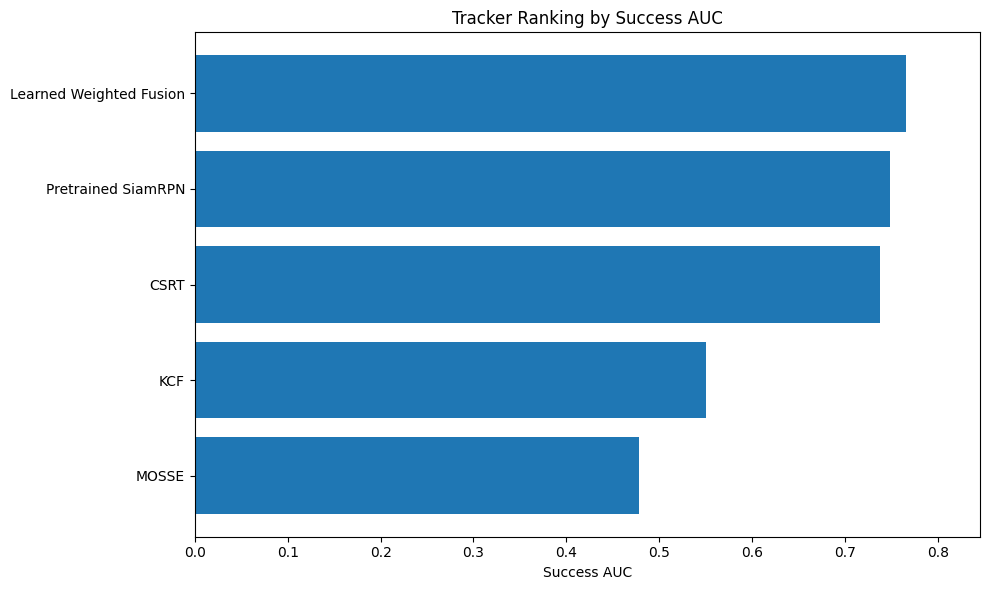

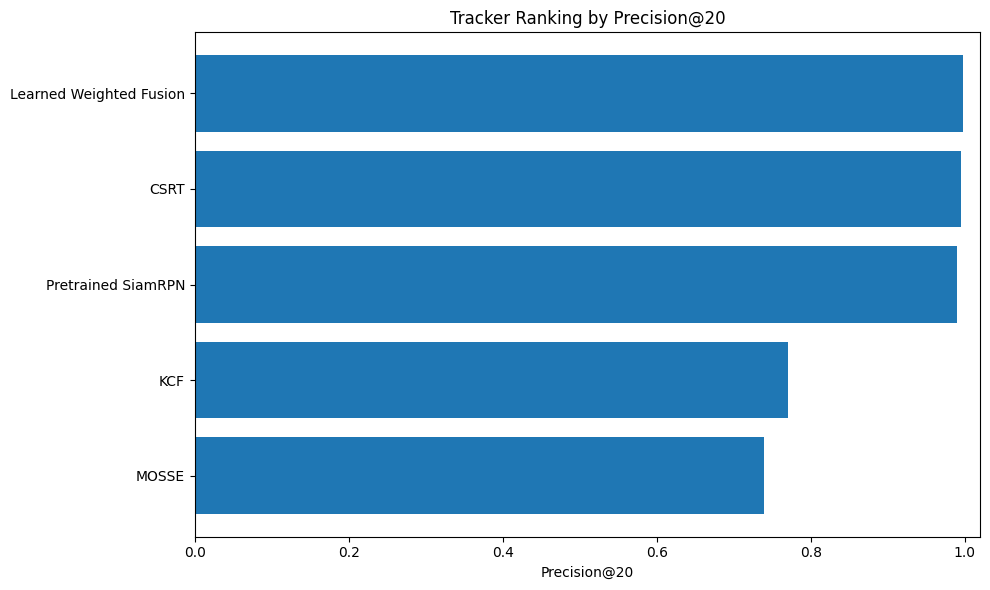

In [ ]:
ranked_success = summary_df.sort_values(
    "success_auc",
    ascending=True,
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    ranked_success[
        "tracker"
    ],
    ranked_success[
        "success_auc"
    ],
)

plt.xlabel("Success AUC")
plt.title(
    "Tracker Ranking by Success AUC"
)
plt.xlim(
    0,
    min(
        1.0,
        max(
            ranked_success[
                "success_auc"
            ].max() + 0.08,
            0.5,
        ),
    ),
)
plt.tight_layout()

success_bar_path = (
    FIGURE_ROOT
    / "success_auc_ranking.png"
)

plt.savefig(
    success_bar_path,
    dpi=300,
)

plt.show()


ranked_precision = summary_df.sort_values(
    "precision_20px",
    ascending=True,
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    ranked_precision[
        "tracker"
    ],
    ranked_precision[
        "precision_20px"
    ],
)

plt.xlabel("Precision@20")
plt.title(
    "Tracker Ranking by Precision@20"
)
plt.xlim(
    0,
    1.02,
)
plt.tight_layout()

precision_bar_path = (
    FIGURE_ROOT
    / "precision_20_ranking.png"
)

plt.savefig(
    precision_bar_path,
    dpi=300,
)

plt.show()


## 12. Fusion improvement table


In [ ]:
fusion_row = summary_df.loc[
    summary_df[
        "tracker"
    ] == "Learned Weighted Fusion"
]

if fusion_row.empty:
    raise RuntimeError(
        "Fusion result is missing."
    )

fusion_row = fusion_row.iloc[0]

comparison_to_fusion = summary_df.loc[
    summary_df[
        "tracker"
    ] != "Learned Weighted Fusion"
].copy()

comparison_to_fusion[
    "fusion_success_gain"
] = (
    float(
        fusion_row[
            "success_auc"
        ]
    )
    - comparison_to_fusion[
        "success_auc"
    ]
)

comparison_to_fusion[
    "fusion_precision_gain"
] = (
    float(
        fusion_row[
            "precision_20px"
        ]
    )
    - comparison_to_fusion[
        "precision_20px"
    ]
)

comparison_to_fusion[
    "fusion_better_success"
] = (
    comparison_to_fusion[
        "fusion_success_gain"
    ] > 0
)

comparison_to_fusion[
    "fusion_better_precision"
] = (
    comparison_to_fusion[
        "fusion_precision_gain"
    ] > 0
)

comparison_to_fusion = (
    comparison_to_fusion
    .sort_values(
        "success_auc",
        ascending=False,
    )
)

display(comparison_to_fusion)

comparison_to_fusion.to_csv(
    COMPARISON_ROOT
    / "fusion_improvement_vs_trackers.csv",
    index=False,
)


,tracker,success_auc,precision_20px,fps,rank_success,rank_precision,fusion_success_gain,fusion_precision_gain,fusion_better_success,fusion_better_precision
1,Pretrained SiamRPN,0.748687,0.989899,NaN,2,3,0.016755,0.007576,True,True
2,CSRT,0.737841,0.994949,32.840883,3,2,0.027601,0.002525,True,True
3,KCF,0.549912,0.770202,115.492338,4,4,0.215530,0.227273,True,True
4,MOSSE,0.478712,0.739899,2.584833,5,5,0.286730,0.257576,True,True


## 13. Paper-ready result text


In [ ]:
top_competitor = (
    summary_df.loc[
        summary_df[
            "tracker"
        ] != "Learned Weighted Fusion"
    ]
    .sort_values(
        "success_auc",
        ascending=False,
    )
    .iloc[0]
)

result_text = f'''
## Same-protocol tracker comparison

The Learned Weighted Fusion tracker achieved:

- Success AUC: {fusion_row["success_auc"]:.3f}
- Precision@20: {fusion_row["precision_20px"]:.3f}

The strongest non-fusion tracker was {top_competitor["tracker"]}, which achieved:

- Success AUC: {top_competitor["success_auc"]:.3f}
- Precision@20: {top_competitor["precision_20px"]:.3f}

The Fusion framework improved Success AUC by:

{fusion_row["success_auc"] - top_competitor["success_auc"]:.3f}

and Precision@20 by:

{fusion_row["precision_20px"] - top_competitor["precision_20px"]:.3f}

These values were measured on the same {len(SEQUENCE_NAMES)}-sequence OTB subset, using at most {MAX_FRAMES} frames per sequence.
'''

print(result_text)

(
    COMPARISON_ROOT
    / "paper_result_text.md"
).write_text(
    result_text,
    encoding="utf-8",
)



## Same-protocol tracker comparison

The Learned Weighted Fusion tracker achieved:

- Success AUC: 0.765
- Precision@20: 0.997

The strongest non-fusion tracker was Pretrained SiamRPN, which achieved:

- Success AUC: 0.749
- Precision@20: 0.990

The Fusion framework improved Success AUC by:

0.017

and Precision@20 by:

0.008

These values were measured on the same 4-sequence OTB subset, using at most 100 frames per sequence.



431

# Expanding the comparison

MOSSE, KCF, CSRT, SiamRPN, and Fusion are evaluated directly by this notebook.

To include SiamFC, SiamRPN++, ECO, ATOM, or DiMP, place their trajectory files in:

```text
/content/drive/MyDrive/OTB_Tracker_Results/<Tracker>/<Sequence>.txt
```

Each row must contain:

```text
x,y,width,height
```

The notebook will automatically include a tracker only when all selected sequences are present.

For paper-quality reporting, later expand `SEQUENCE_NAMES` and set `MAX_FRAMES = None`.
